In [1]:
# --- Librerías de manipulación de datos y cálculo numérico ---
import numpy as np       # Álgebra lineal y manejo de arrays multidimensionales
import pandas as pd      # Estructuras de datos (DataFrames) para análisis y limpieza
import matplotlib.pyplot as plt  # Visualización de datos y gráficas
import random            # Generador de números aleatorios nativo de Python

# --- Librerías de Machine Learning y Preprocesamiento ---
from sklearn.model_selection import train_test_split  # Para dividir el dataset en entrenamiento y prueba

# --- Ecosistema TensorFlow / Keras para Deep Learning ---
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer      # Convierte texto en tokens (índices numéricos)
from tensorflow.keras.preprocessing.sequence import pad_sequences # Homogeniza la longitud de las secuencias (relleno)

# --- Componentes para la construcción del modelo ---
from tensorflow.keras.models import Sequential               # Modelo lineal capa por capa
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Input # Capas específicas para NLP
from tensorflow.keras.optimizers import Adam                 # Algoritmo de optimización

# --- Configuración de Reproductibilidad ---
# Fijamos las semillas para asegurar que los resultados sean los mismos cada vez que se ejecute el código
np.random.seed(42)       # Semilla para NumPy
tf.random.set_seed(42)   # Semilla para TensorFlow/Keras
random.seed(42)          # Semilla para el módulo random de Python

**Creando dataset para resolver un problema de Desambiguación de Sentido de Palabras (WSD)**

Dataset con palabras ambiguas:

$0$ = sentido fisico / concreto / literal


$1$ = sentido alternativo / institucional / abstracto

In [7]:
frases=[]
etiquetas=[]

**BANCO**

$0$ = asiento / banca


$1$ = institucion financiera


In [13]:
banco_fisico = [
    "me sente en el banco de la plaza", "el banco del parque estaba mojado", "pintaron el banco de madera de color azul",
    "el niño salto sobre el banco del jardin","arreglaron el banco frente a la fuente", "el banco viejo estaba roto por la lluvia", 
    "dejaron la mochila encima del banco del parque","el banco de la escuela era muy incomodo", "la banca de concreto estaba fria en la mañana", 
    "encontramos un banco vacio junto al arbol", "el abuelo descansa en el banco de piedra",    "movieron el banco de hierro hacia la sombra",
    "el banco del muelle tiene vista al mar",    "construyeron un banco rustico con troncos",   "el carpintero barnizo el banco ayer",
    "nos sentamos en el banco a comer un helado", "el banco de la parada del autobus esta sucio",    "las palomas se posaron en el banco vacio",
    "rompieron el respaldo del banco publico",    "limpiaron el banco antes de sentarse"
]

banco_financiero = [
    "el banco aprobo el credito del cliente", "el banco central anuncio nuevas tasas", "la sucursal del banco abrio muy temprano",
    "el banco rechazo la solicitud del prestamo","los clientes entraron al banco principal",    "el banco reporto ganancias este trimestre",
    "la directora del banco dio una conferencia",    "el banco aumento la tasa de interes", "la cuenta del banco fue bloqueada",
    "el banco ofrecio un nuevo producto financiero", "fui al banco a depositar mi quincena",    "el cajero del banco me dio billetes falsos",
    "la aplicacion del banco esta fallando hoy",    "el banco internacional abriuna sede aqui",    "me llamaron del banco para ofrecer una tarjeta",  
    "el banco me cobra comisiones muy altas",    "transferi los fondos a otro banco",
    "el gerente del banco firmo los documentos",    "el banco hipotecario financio mi casa",    "hay mucha gente esperando afuera del banco"
]

**CURA**

$0$ = tratamiento médico


$1$ = sacerdote

In [17]:
cura_tratamiento = [
    "la cura fue efectiva para el paciente","los medicos probaron una nueva cura", "la cura redujo los sintomas rapidamente", 
    "esperan encontrar una cura definitiva",
    "la cura experimental funciono en el hospital",  "la cura tardo semanas en hacer efecto",    "la investigacion busca una cura estable",
    "la cura medica fue aprobada este año",    "la cura alivio el dolor del enfermo",
    "los cientificos desarrollan una cura innovadora",    "la cura para el virus aun esta en desarrollo","aplicaron la cura mediante una inyeccion",
    "el laboratorio patento la nueva cura",    "la cura milagrosa resulto ser un fraude",    "el paciente reacciono bien a la cura",
    "descubrieron la cura despues de años de estudio",    "la cura tropical se extrae de una planta",    "no existe una cura conocida para este mal",
    "la cura alternativa mejoro su salud",    "el tratamiento es una cura a largo plazo"
]

cura_sacerdote = [
    "el cura pronuncio un discurso en la iglesia","el cura saludo a los asistentes de la misa",
    "el cura hablo con la comunidad del pueblo",    "el cura organizo una reunion parroquial",
    "el cura bendijo a los recien casados",    "el cura visito a varias familias del barrio","el cura encendio las velas del altar",
    "el cura escucho las confesiones del domingo",    "el cura acompaño la procesion de la tarde",    "el cura explico el mensaje del evangelio",
    "el cura de la catedral es muy estricto",    "el cura ofició el bautizo esta mañana","el cura pidio donaciones para los huerfanos",
    "el cura rezo el rosario con los fieles",    "el cura del monasterio vive en silencio",    "el cura llevo la comunion a los enfermos",
    "el cura vistio su tunica blanca",    "el cura joven llego a la parroquia hoy",    "el cura toco las campanas al mediodia",
    "el cura leyo un pasaje de la biblia"
]

**CAPITAL**

$0$ = dinero / recurso financiero

$1$ = ciudad principal


In [20]:
capital_dinero = [
    "la empresa aumento su capital este año","el inversionista perdio gran parte del capital",    "necesitan mas capital para crecer",
    "el capital inicial fue insuficiente",    "la firma extranjera inyecto capital nuevo",    "el capital privado financio el proyecto",
    "la startup consiguio capital de riesgo",    "el capital acumulado mejoro la operacion",    "el negocio requiere capital adicional",
    "el capital disponible se redujo por la crisis",    "el capital humano es lo mas importante de la empresa",    "sin capital no podemos abrir el restaurante",
    "los socios aportaron el capital necesario",    "el flujo de capital fue constante",    "el banco congelo el capital de la corporacion",
    "el capital invertido genero grandes rendimientos",    "fugaron su capital a cuentas en el extranjero",    "el capital social de la compañia aumento",
    "compraron maquinaria con su propio capital",    "el exceso de capital provoco inflacion"
]

capital_ciudad = [
    "la capital del pais recibe muchos turistas",    "viajaron a la capital para una reunion","la capital concentro el poder politico",
    "la capital amanecio con mucho trafico",    "la capital fue fundada hace siglos",    "los museos de la capital estaban llenos",
    "la capital se preparo para el desfile",    "la capital tiene una gran poblacion",    "el tren llego a la capital al amanecer",
    "la capital organiza eventos internacionales",    "el presidente dio un discurso en la capital",    "la capital de francia es muy hermosa",
    "los vuelos hacia la capital estan retrasados",    "hubo protestas en el centro de la capital",    "el alcalde de la capital inauguro un puente",
    "la capital financiera atrae muchos negocios",    "el clima en la capital es muy frio",    "la vida en la capital es muy acelerada",
    "el gobierno mudo sus oficinas a la capital",    "la capital provincial celebra sus fiestas"
]

**RATON**

$0$ = animal

$1$ = dispositivo de computadora

In [24]:
raton_animal = [
    "el raton corrio debajo de la mesa",    "el gato persiguio al raton gris",    "el raton salio de su escondite",
    "un raton pequeño aparecio en la cocina",    "el raton se movio entre las cajas",    "escucharon al raton durante la noche",
    "el raton royo una bolsa de pan",    "el raton huyo cuando encendieron la luz",    "vieron un raton cerca del almacen",
    "el raton se escondio tras el armario",    "pusieron una trampa de queso para el raton",    "el buho atrapo un raton en el bosque",
    "el raton de campo destruyo la cosecha",    "el laboratorio usa un raton blanco para pruebas",    "el raton es un roedor muy escurridizo",
    "hay un nido de raton en el atico",    "el raton asusto a todos en el comedor",    "el raton mordio los cables del motor",
    "el aguila detecto al raton desde el cielo", "el raton chillo cuando lo acorralaron"
]

raton_dispositivo = [
    "el raton dejo de funcionar en la oficina",    "compre un raton inalambrico para la laptop", "el raton optico era muy preciso",
    "cambio la bateria del raton bluetooth",    "el raton de la computadora estaba roto",    "necesito un raton ergonomico para trabajar",
    "el raton respondia con retraso",    "limpiaron el sensor del raton",    "conecte el raton a un puerto usb",
    "el raton nuevo tenia varios botones",    "hice clic derecho con el raton",    "el cursor del raton desaparecio de la pantalla",
    "compre una alfombrilla para deslizar el raton",    "la rueda del raton hace un ruido raro", "el raton gamer tiene luces de colores",
    "el raton se desconecto repentinamente", "arrastre la ventana usando el raton", "el raton tactil de la laptop es incomodo",
    "configure la velocidad de movimiento del raton",    "el cable del raton se enredo en el teclado"
]

**COLA**

$0$ = fila de personas

$1$ = parte del animal

In [28]:
cola_fila = [
    "la cola avanzaba lentamente en la entrada", "hicimos cola durante dos horas", "la cola del cine daba vuelta a la esquina",  
    "la cola para pagar era enorme","la cola del supermercado fue muy larga",    "la cola comenzo antes del amanecer",
    "la cola de clientes llego hasta la calle",    "la cola se movio mas rapido despues",    "todos esperaron en cola con paciencia",
    "la cola del estadio bloqueo el paso",    "me meti en la cola equivocada en el banco",    "la cola del peaje causaba mucho trafico",
    "alguien se metio en la cola sin permiso",    "la cola de la taquilla avanza por turnos",    "esperamos al final de la cola",
    "la cola para subir al avion ya empezo",    "hicimos cola bajo la lluvia intensa","la cola del concierto estaba llena de jovenes",
    "no soporto estar en una cola tan lenta",    "el guardia organizo la cola de personas"
]

cola_animal = [
    "el perro movia la cola sin parar",    "la cola del gato estaba erizada",    "el caballo golpeo la cola contra el aire",
    "la cola del zorro era muy espesa",    "la cola del mono colgaba del arbol",    "el veterinario reviso la cola del animal",
    "la cola del leon se movia despacio",    "el pez perdio parte de la cola",    "la cola de la ardilla era enorme",
    "la cola del perro estaba mojada",    "el reptil mudo la piel de su cola",    "el pavo real desplego su hermosa cola",
    "la lagartija perdio la cola al escapar",    "el escorpion ataco con la punta de su cola",    "el castor golpeo el agua con la cola",
    "la sirena tenia una brillante cola de pez",    "la cola del cocodrilo es muy pesada",    "el lobo escondio la cola entre las patas",
    "el pajaro tenia plumas rojas en la cola",    "la cola del tigre es larga y rayada"
]

In [30]:
# --- Definición de la función de carga de datos ---
def agregar_ejemplos(lista_frases, etiqueta):
    """
    Recorre una lista de oraciones y las añade a las listas globales 'frases' 
    y 'etiquetas', asignándoles la clase numérica correspondiente.
    """
    for frase in lista_frases:
        frases.append(frase)      # Añade el texto a la lista maestra de entrada
        etiquetas.append(etiqueta) # Añade la respuesta correcta (0 o 1) a la lista maestra de salida

# --- Poblamiento del Dataset (Estructuración de Clases) ---
# Clasificamos cada categoría según su semántica: 
# 0 = Sentido físico / literal | 1 = Sentido institucional / abstracto / técnico

# Caso: BANCO
agregar_ejemplos(banco_fisico, 0)      # Banco como asiento
agregar_ejemplos(banco_financiero, 1)  # Banco como entidad

# Caso: CURA
agregar_ejemplos(cura_tratamiento, 0) # Cura como medicina
agregar_ejemplos(cura_sacerdote, 1)   # Cura como clérigo

# Caso: CAPITAL
agregar_ejemplos(capital_dinero, 0)   # Capital como recurso financiero
agregar_ejemplos(capital_ciudad, 1)   # Capital como sede política

# Caso: RATÓN
agregar_ejemplos(raton_animal, 0)     # Ratón como roedor
agregar_ejemplos(raton_dispositivo, 1) # Ratón como hardware

# Caso: COLA
agregar_ejemplos(cola_fila, 0)        # Cola como fila de personas
agregar_ejemplos(cola_animal, 1)      # Cola como apéndice físico

In [34]:
# --- Creación del objeto DataFrame ---
# Convertimos las listas maestras en una tabla (DataFrame) con dos columnas: 
# una para el texto ('frase') y otra para la categoría ('etiqueta').
df = pd.DataFrame({
    "frase": frases,
    "etiqueta": etiquetas
})
df

,frase,etiqueta
0,me sente en el banco de la plaza,0
1,el banco del parque estaba mojado,0
2,pintaron el banco de madera de color azul,0
3,el niño salto sobre el banco del jardin,0
4,arreglaron el banco frente a la fuente,0
...,...,...
195,la sirena tenia una brillante cola de pez,1
196,la cola del cocodrilo es muy pesada,1
197,el lobo escondio la cola entre las patas,1
198,el pajaro tenia plumas rojas en la cola,1


In [36]:
# --- Mezcla Aleatoria (Shuffle) ---
# Es crucial que el modelo no reciba primero todos los ceros y luego todos los unos.
# .sample(frac=1): Toma el 100% de los datos y los desordena al azar.
# random_state=42: Asegura que el "desorden" sea reproducible (siempre el mismo).
# .reset_index(drop=True): Reorganiza los números de fila para que vayan de 0 en adelante.
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# --- Verificación de la estructura ---
# Mostramos las primeras 10 filas para confirmar que los sentidos (0 y 1) están mezclados.
print(df.head(10))

# Imprimimos la cantidad total de oraciones recolectadas.
print("\nTotal de ejemplos:", len(df))

# --- Verificación de Balance ---
# Contamos cuántos ejemplos hay de cada clase. 
# Esto asegura que no haya un desbalance que pueda confundir al modelo.
print("\nBalance de clases:")
print(df["etiqueta"].value_counts())

                                              frase  etiqueta
0  el capital invertido genero grandes rendimientos         0
1        nos sentamos en el banco a comer un helado         0
2              fui al banco a depositar mi quincena         1
3    configure la velocidad de movimiento del raton         1
4                 vieron un raton cerca del almacen         0
5       la capital financiera atrae muchos negocios         1
6          el cura explico el mensaje del evangelio         1
7         me meti en la cola equivocada en el banco         0
8                     esperamos al final de la cola         0
9             la cura tardo semanas en hacer efecto         0

Total de ejemplos: 200

Balance de clases:
etiqueta
0    100
1    100
Name: count, dtype: int64


In [38]:
# --- Preparación de datos para Procesamiento de Lenguaje Natural (NLP) ---

# 1. Convertimos las columnas del DataFrame a listas de Python para el procesamiento
X = df["frase"].tolist()   # Textos (Entrada)
y = df['etiqueta'].tolist() # Etiquetas (Salida)

# 2. División del dataset en Entrenamiento y Prueba
# test_size=0.2: Reservamos el 20% de los datos para evaluar el modelo al final.
# stratify=y: Garantiza que la proporción de ceros y unos sea la misma en ambos conjuntos.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y
)

# 3. Tokenización
# oov_token="<OOV>": Asigna una etiqueta especial a palabras nuevas que aparezcan 
# en el test pero no estuvieran en el entrenamiento (Out Of Vocabulary).
tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(X_train) # El "diccionario" se construye solo con datos de entrenamiento

# 4. Conversión de texto a números
# Cada palabra se sustituye por su índice numérico según el vocabulario creado.
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# 5. Cálculo de la longitud máxima
# Buscamos la frase con más palabras para definir el tamaño de entrada de la red.
max_len = max(len(seq) for seq in X_train_seq)

# 6. Padding (Relleno de secuencias)
# Las redes neuronales requieren que todas las entradas tengan el mismo tamaño.
# padding="post": Añade ceros al final de las frases cortas hasta alcanzar 'max_len'.
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding="post")

# 7. Tamaño del vocabulario
# Sumamos 1 porque el índice 0 está reservado para el padding.
vocab_size = len(tokenizer.word_index) + 1

# --- Resumen de la transformación ---
print("Vocabulario:", vocab_size)       # Total de palabras únicas detectadas
print("max_len:", max_len)               # Número de columnas que tendrá nuestra matriz
print("Dimensiones de X_train:", X_train_pad.shape) # (Ejemplos, Palabras por frase)
print("Dimensiones de X_test:", X_test_pad.shape)

Vocabulario: 485
max_len: 10
Dimensiones de X_train: (160, 10)
Dimensiones de X_test: (40, 10)


In [42]:
# --- Arquitectura del Modelo LSTM Simple ---

modelo_lstm_simple = Sequential()

# 1. Capa de Entrada: Define el tamaño de las secuencias que entrarán (max_len)
modelo_lstm_simple.add(Input(shape=(max_len,)))

# 2. Capa de Embedding (Incrustación): 
# Transforma los números enteros (índices) en vectores densos de 32 dimensiones.
# mask_zero=True: Le dice al modelo que ignore los ceros del 'padding', 
# para que no aprenda patrones de los rellenos vacíos.
modelo_lstm_simple.add(Embedding(input_dim=vocab_size, output_dim=32, mask_zero=True))

# 3. Capa LSTM:
# La unidad de memoria con 32 neuronas. Procesa la secuencia palabra por palabra 
# y extrae el significado contextual de la frase.
modelo_lstm_simple.add(LSTM(32))

# 4. Capa de Salida (Dense):
# Una sola neurona con activación "sigmoid". 
# Devuelve un valor entre 0 y 1 (probabilidad de pertenecer a la clase 1).
modelo_lstm_simple.add(Dense(1, activation="sigmoid"))

# --- Configuración del Entrenamiento ---
modelo_lstm_simple.compile(
    optimizer=Adam(learning_rate=0.001), # Optimizador adaptativo, el estándar de la industria
    loss="binary_crossentropy",          # Función de pérdida para clasificación binaria (0 o 1)
    metrics=["accuracy"]                 # Queremos medir el porcentaje de aciertos (precisión)
)

# Muestra un resumen de la estructura, parámetros y capas del modelo
modelo_lstm_simple.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ (None, 10, 32)              │          15,520 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,873 (93.25 KB)

 Trainable params: 23,873 (93.25 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
# --- Arquitectura del Modelo LSTM Bidireccional (BiLSTM) ---

modelo_bilstm = Sequential()

# 1. Capa de Entrada: Recibe las secuencias con la longitud máxima calculada
modelo_bilstm.add(Input(shape=(max_len,)))

# 2. Capa de Embedding:
# Convierte los índices de palabras en vectores de 32 dimensiones.
# mask_zero=True es fundamental aquí para que la bidireccionalidad no se confunda con el padding.
modelo_bilstm.add(Embedding(input_dim=vocab_size, output_dim=32, mask_zero=True))

# 3. Capa BiLSTM (Bidireccional):
# Envuelve la capa LSTM para procesar la información en dos direcciones.
# Esto permite que la palabra "banco" se entienda no solo por lo que vino antes, 
# sino también por las palabras que vienen después en la misma frase.
modelo_bilstm.add(Bidirectional(LSTM(32)))

# 4. Capa de Salida:
# Clasificación binaria (0 o 1) mediante la función sigmoide.
modelo_bilstm.add(Dense(1, activation="sigmoid"))

# --- Compilación del Modelo ---
modelo_bilstm.compile(
    optimizer=Adam(learning_rate=0.001), # Optimizador Adam para un aprendizaje eficiente
    loss="binary_crossentropy",          # Ideal para problemas de dos clases
    metrics=["accuracy"]                 # Monitoreamos la precisión durante el entrenamiento
)

# Muestra la tabla de parámetros (notarás que la BiLSTM tiene el doble de parámetros que la LSTM simple)
modelo_bilstm.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)              │ (None, 10, 32)              │          15,520 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 64)                  │          16,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 32,225 (125.88 KB)

 Trainable params: 32,225 (125.88 KB)

 Non-trainable params: 0 (0.00 B)

In [46]:
# --- Arquitectura de Red Neuronal Profunda (Stacked BiLSTM) ---

modelo_bilstm_profunda = Sequential()

# 1. Capa de Entrada: Tamaño basado en la frase más larga
modelo_bilstm_profunda.add(Input(shape=(max_len,)))

# 2. Capa de Embedding: Espacio vectorial de 32 dimensiones con máscara de ceros
modelo_bilstm_profunda.add(Embedding(input_dim=vocab_size, output_dim=32, mask_zero=True))

# 3. Primera Capa BiLSTM Apilada:
# return_sequences=True: OBLIGATORIO para apilar. En lugar de dar una respuesta final,
# devuelve la secuencia completa de estados ocultos para que la siguiente capa los procese.
# recurrent_dropout=0.2: Técnica de regularización que "apaga" aleatoriamente conexiones 
# de la memoria interna para evitar el sobreajuste (overfitting).
modelo_bilstm_profunda.add(Bidirectional(LSTM(32, return_sequences=True, recurrent_dropout=0.2)))

# 4. Segunda Capa BiLSTM:
# Aquí return_sequences=False (por defecto), ya que esta capa resume toda la 
# información en un único vector antes de pasar a la clasificación.
modelo_bilstm_profunda.add(Bidirectional(LSTM(32, recurrent_dropout=0.2)))

# 5. Capa de Salida: Clasificador binario (Sigmoide)
modelo_bilstm_profunda.add(Dense(1, activation="sigmoid"))

# --- Configuración del proceso de aprendizaje ---
modelo_bilstm_profunda.compile(
    optimizer=Adam(learning_rate=0.001), 
    loss="binary_crossentropy", 
    metrics=["accuracy"]
)

# Resumen: Verás un salto considerable en el número de parámetros entrenables
modelo_bilstm_profunda.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)              │ (None, 10, 32)              │          15,520 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 10, 64)              │          16,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_2 (Bidirectional)      │ (None, 64)                  │          24,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 57,057 (222.88 KB)

 Trainable params: 57,057 (222.88 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
# --- Proceso de Entrenamiento de los Modelos ---

# Definimos 20 épocas (iteraciones completas sobre el dataset)
# validation_split=0.2 reserva el 20% de los datos de entrenamiento para monitorear 
# si el modelo está aprendiendo bien o si solo está memorizando (overfitting).

# 1. Entrenamiento del Modelo LSTM Simple
print("Entrenando LSTM Simple...")
hist_lstm = modelo_lstm_simple.fit(
    X_train_pad,            # Datos de entrada (frases convertidas a números)
    np.array(y_train),      # Etiquetas reales (0 o 1)
    epochs=20,              # Número de veces que la red verá el dataset completo
    validation_split=0.2,   # Porcentaje para validación durante el entrenamiento
    verbose=0               # NO Muestra el progreso (barra de carga y métricas) por consola
)

# 2. Entrenamiento del Modelo BiLSTM (Bidireccional)
print("\nEntrenando BiLSTM...")
hist_bilstm = modelo_bilstm.fit(
    X_train_pad,
    np.array(y_train),
    epochs=20,
    validation_split=0.2,
    verbose=0
)

# 3. Entrenamiento del Modelo BiLSTM Profunda (Apilada con Dropout)
# Nota: Este modelo suele tardar más tiempo por época debido a su mayor complejidad técnica.
print("\nEntrenando BiLSTM Profunda...")
hist_bilstm_prof = modelo_bilstm_profunda.fit(
    X_train_pad,
    np.array(y_train),
    epochs=20,
    validation_split=0.2,
    verbose=0
)

Entrenando LSTM Simple...

Entrenando BiLSTM...

Entrenando BiLSTM Profunda...


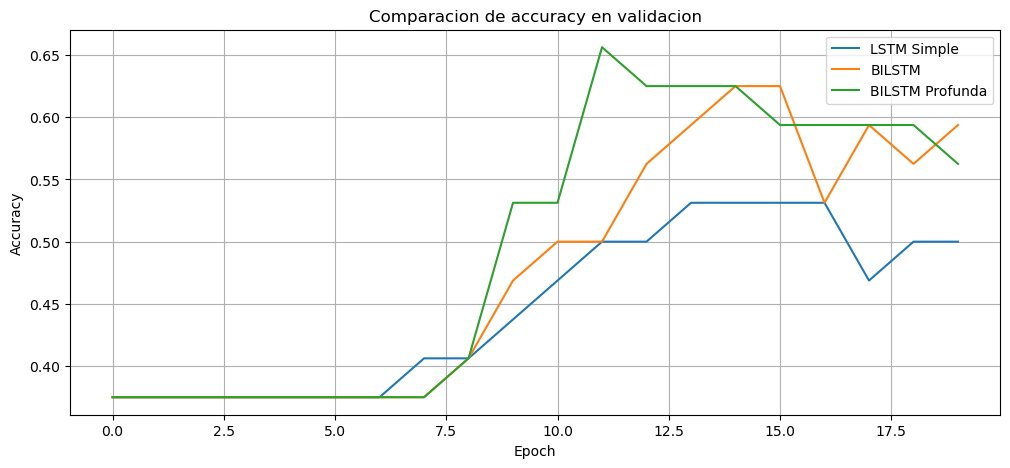

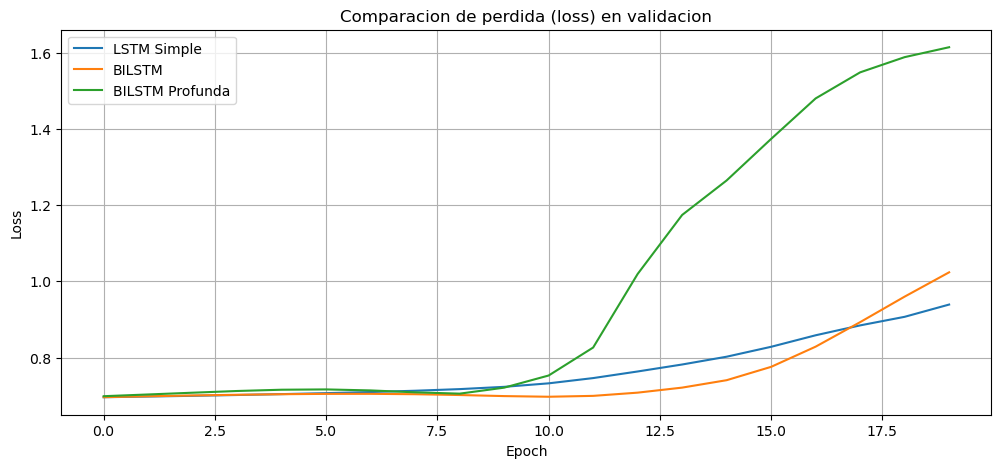

In [50]:
# --- Visualización de resultados con Matplotlib ---

# 1. Gráfica de Precisión (Accuracy)
plt.figure(figsize=(12,5)) # Establecemos el tamaño de la imagen (ancho, alto)

# Graficamos la precisión de validación (val_accuracy) de cada modelo guardada en los objetos 'history'
plt.plot(hist_lstm.history["val_accuracy"], label="LSTM Simple")
plt.plot(hist_bilstm.history["val_accuracy"], label="BILSTM")
plt.plot(hist_bilstm_prof.history["val_accuracy"], label="BILSTM Profunda")

# Configuración estética de la primera gráfica
plt.title("Comparacion de accuracy en validacion") # Título de la gráfica
plt.xlabel("Epoch")   # Etiqueta para el eje X (iteraciones)
plt.ylabel("Accuracy") # Etiqueta para el eje Y (porcentaje de acierto)
plt.legend()           # Muestra el cuadro con los nombres de cada modelo
plt.grid(True)         # Añade una cuadrícula para facilitar la lectura
plt.show()             # Despliega el dibujo en pantalla

# 2. Gráfica de Pérdida (Loss)
plt.figure(figsize=(12,5))

# Graficamos la pérdida de validación (val_loss). 
# Entre más bajo sea este valor, mejor está prediciendo el modelo.
plt.plot(hist_lstm.history["val_loss"], label="LSTM Simple")
plt.plot(hist_bilstm.history["val_loss"], label="BILSTM")
plt.plot(hist_bilstm_prof.history["val_loss"], label="BILSTM Profunda")

# Configuración estética de la segunda gráfica
plt.title("Comparacion de perdida (loss) en validacion")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [52]:
# --- Evaluación Final con Datos Desconocidos (Test Set) ---

# .evaluate devuelve una lista donde el índice [0] es la Pérdida (Loss) 
# y el índice [1] es la Precisión (Accuracy).

# 1. Evaluamos el modelo de una sola dirección
resultado_lstm = modelo_lstm_simple.evaluate(
    X_test_pad, 
    np.array(y_test), 
    verbose=0 # verbose=0 para que no muestre la barra de progreso y la salida sea limpia
)

# 2. Evaluamos el modelo bidireccional
resultado_bilstm = modelo_bilstm.evaluate(
    X_test_pad, 
    np.array(y_test), 
    verbose=0
)

# 3. Evaluamos el modelo con capas apiladas y dropout
resultado_bilstm_prof = modelo_bilstm_profunda.evaluate(
    X_test_pad, 
    np.array(y_test), 
    verbose=0
)

# --- Impresión de Reporte Comparativo ---
print("Resultados en test:")

# Usamos f-strings para formatear los números a 4 decimales (.4f)
print(f"LSTM simple            Loss: {resultado_lstm[0]:.4f} | Accuracy: {resultado_lstm[1]:.4f}")
print(f"BILSTM                 Loss: {resultado_bilstm[0]:.4f} | Accuracy: {resultado_bilstm[1]:.4f}")
print(f"BILSTM profunda        Loss: {resultado_bilstm_prof[0]:.4f} | Accuracy: {resultado_bilstm_prof[1]:.4f}")

Resultados en test:
LSTM simple            Loss: 1.0299 | Accuracy: 0.6000
BILSTM                 Loss: 1.1425 | Accuracy: 0.5000
BILSTM profunda        Loss: 2.1881 | Accuracy: 0.5500


In [54]:
# --- Prueba de Inferencia con Frases Nuevas (Predicción) ---

# 1. Definición de nuevos casos de prueba
frases_nuevas = [
    "el banco estaba frente al parque",             # Esperado: 0 (Físico)
    "el banco aprobo el credito del cliente",        # Esperado: 1 (Institucional)
    "la cura fue efectiva para el paciente",         # Esperado: 0 (Físico/Médico)
    "el cura pronuncio un discurso en la iglesia"    # Esperado: 1 (Institucional/Religioso)
]

# 2. Preprocesamiento de las nuevas frases
# Es vital usar el MISMO tokenizer y el MISMO padding que en el entrenamiento
seq_nuevas = tokenizer.texts_to_sequences(frases_nuevas)
pad_nuevas = pad_sequences(seq_nuevas, maxlen=max_len, padding="post")

# 3. Ejecución de las predicciones en los tres modelos
# predict() devuelve una probabilidad entre 0 y 1
preds = {
    "LSTM Simple": modelo_lstm_simple.predict(pad_nuevas, verbose=0),
    "BiLSTM": modelo_bilstm.predict(pad_nuevas, verbose=0),
    "BiLSTM Profunda": modelo_bilstm_profunda.predict(pad_nuevas, verbose=0)
}

# 4. Formateo y Visualización de Resultados
print("🔍 RESULTADOS DE DESAMBIGUACIÓN:")
print("="*90)

for i, frase in enumerate(frases_nuevas):
    print(f"📝 Frase: '{frase}'")
    
    for nombre_modelo, predicciones in preds.items():
        probabilidad = predicciones[i][0]
        
        # Interpretación del sentido basado en el umbral de 0.5
        # 0 = Físico / 1 = Abstracto
        sentido = "INSTITUCIONAL/ABSTRACTO (1)" if probabilidad > 0.5 else "FÍSICO/CONCRETO (0)"
        
        # Mostramos el nombre del modelo, la probabilidad y la etiqueta interpretada
        print(f" 🤖 {nombre_modelo.ljust(18)}: Prob: {probabilidad:.4f} -> Sentido: {sentido}")
    
    print("-" * 90)

🔍 RESULTADOS DE DESAMBIGUACIÓN:
📝 Frase: 'el banco estaba frente al parque'
 🤖 LSTM Simple       : Prob: 0.1489 -> Sentido: FÍSICO/CONCRETO (0)
 🤖 BiLSTM            : Prob: 0.0278 -> Sentido: FÍSICO/CONCRETO (0)
 🤖 BiLSTM Profunda   : Prob: 0.0010 -> Sentido: FÍSICO/CONCRETO (0)
------------------------------------------------------------------------------------------
📝 Frase: 'el banco aprobo el credito del cliente'
 🤖 LSTM Simple       : Prob: 0.5799 -> Sentido: INSTITUCIONAL/ABSTRACTO (1)
 🤖 BiLSTM            : Prob: 0.8130 -> Sentido: INSTITUCIONAL/ABSTRACTO (1)
 🤖 BiLSTM Profunda   : Prob: 0.9141 -> Sentido: INSTITUCIONAL/ABSTRACTO (1)
------------------------------------------------------------------------------------------
📝 Frase: 'la cura fue efectiva para el paciente'
 🤖 LSTM Simple       : Prob: 0.0463 -> Sentido: FÍSICO/CONCRETO (0)
 🤖 BiLSTM            : Prob: 0.0140 -> Sentido: FÍSICO/CONCRETO (0)
 🤖 BiLSTM Profunda   : Prob: 0.0010 -> Sentido: FÍSICO/CONCRETO (0)
-------

# Generación de texto

In [57]:
# Colocar el corpus para la generacion de texto
corpus = [
    # IA
    "la inteligencia artificial aprende patrones",
    "la inteligencia artificial procesa secuencias",
    "la inteligencia artificial necesita datos",
    "la inteligencia artificial transforma industrias",
    "la inteligencia artificial analiza imagenes",
    "la inteligencia artificial mejora procesos",
    "la inteligencia artificial detecta anomalias",
    "la inteligencia artificial puede clasificar texto",
    "la inteligencia artificial ayuda en medicina",
    "la inteligencia artificial requiere evaluacion",

    # redes neuronales
    "las redes neuronales aprenden representaciones",
    "las redes neuronales ajustan pesos",
    "las redes neuronales detectan regularidades",
    "las redes neuronales modelan relaciones complejas",
    "las redes neuronales requieren entrenamiento",
    "las redes neuronales pueden sobreajustar",
    "las redes neuronales usan funciones de activacion",
    "las redes neuronales generan salidas probabilisticas",
    "las redes neuronales dependen de la arquitectura",
    "las redes neuronales capturan patrones ocultos",

    # LSTM
    "las lstm recuerdan informacion importante",
    "las lstm usan compuertas para controlar memoria",
    "las lstm reducen el gradiente desvaneciente",
    "las lstm manejan secuencias largas",
    "las lstm separan estado oculto y celda",
    "las lstm procesan lenguaje natural",
    "las lstm mejoran la memoria temporal",
    "las lstm filtran informacion irrelevante",
    "las lstm conservan contexto a largo plazo",
    "las lstm pueden generar texto",

    # BiLSTM
    "las bilstm leen en dos direcciones",
    "las bilstm usan contexto pasado y futuro",
    "las bilstm mejoran la desambiguacion",
    "las bilstm enriquecen la representacion",
    "las bilstm ayudan en clasificacion de secuencias",
    "las bilstm capturan contexto global",
    "las bilstm se usan en nlp",
    "las bilstm son utiles para etiquetado",
    "las bilstm combinan dos recorridos",
    "las bilstm interpretan mejor frases ambiguas",

    # softmax y salida
    "la salida softmax produce probabilidades",
    "la salida softmax distribuye masa entre tokens",
    "la softmax convierte logits en probabilidades",
    "la softmax normaliza la salida del modelo",
    "la softmax se usa en modelos generativos",
    "la probabilidad mayor no siempre es la elegida",
    "la temperatura controla la diversidad",
    "la temperatura modifica el muestreo",
    "la distribucion softmax guia la generacion",
    "la red estima el siguiente token probable",

    # generación
    "el siguiente token depende de la historia",
    "la generacion autoregresiva repite el proceso",
    "el modelo recibe un prompt inicial",
    "la red predice una palabra nueva",
    "el token generado vuelve al contexto",
    "la generacion continua paso a paso",
    "la secuencia crece palabra por palabra",
    "el muestreo selecciona una continuacion",
    "la generacion depende de probabilidades",
    "la red construye texto iterativamente",

    # regularización
    "el dropout recurrente protege la memoria",
    "el dropout recurrente mantiene la misma mascara",
    "el dropout tradicional rompe la secuencia",
    "la regularizacion evita overfitting",
    "el modelo profundo puede memorizar demasiado",
    "la validacion mide generalizacion",
    "la perdida de validacion puede crecer",
    "el sobreajuste daña el rendimiento futuro",
    "las capas profundas necesitan control",
    "la regularizacion mejora robustez",

    # límite secuencial
    "la generacion secuencial limita la paralelizacion",
    "el procesamiento paso a paso reduce eficiencia",
    "las gpus prefieren operaciones paralelas",
    "la secuencia estricta crea un cuello de botella",
    "los contextos grandes aumentan el costo",
    "el hardware no se aprovecha completamente",
    "la memoria secuencial tiene limites",
    "el tiempo de inferencia crece con la longitud",
    "la paralelizacion parcial sigue siendo dificil",
    "ese limite abrio paso a transformers"
]


In [59]:
print("Total de frases del corpus:", len(corpus))
print("\nPrimeras 10 frases:")
for frase in corpus [:10]:
  print("-", frase)

Total de frases del corpus: 80

Primeras 10 frases:
- la inteligencia artificial aprende patrones
- la inteligencia artificial procesa secuencias
- la inteligencia artificial necesita datos
- la inteligencia artificial transforma industrias
- la inteligencia artificial analiza imagenes
- la inteligencia artificial mejora procesos
- la inteligencia artificial detecta anomalias
- la inteligencia artificial puede clasificar texto
- la inteligencia artificial ayuda en medicina
- la inteligencia artificial requiere evaluacion


In [61]:
# --- Configuración del Tokenizer para Generación de Texto ---

# 1. Inicializamos un nuevo Tokenizer 
# En generación de texto, normalmente no usamos el token <OOV> del mismo modo que en 
# clasificación, ya que el modelo solo podrá generar palabras que ya conoce del corpus.
tokenizer_gen = Tokenizer()

# 2. Construcción del vocabulario
# El método 'fit_on_texts' escanea todo el 'corpus', identifica las palabras únicas 
# y les asigna un índice numérico basado en su frecuencia (la palabra más común será el 1).
tokenizer_gen.fit_on_texts(corpus)

# 3. Cálculo del tamaño del vocabulario
# Sumamos +1 para considerar el índice 0, que se utiliza para el padding (relleno).
# Este valor es crucial porque define la dimensión de salida de nuestra futura red neuronal.
total_words = len(tokenizer_gen.word_index) + 1

# --- Verificación del Vocabulario ---
print("Tamaño del vocabulario generativo:", total_words)
print("\nPrimeras palabras del vocabulario (las más frecuentes):")

# 4. Inspección de los primeros tokens
# Recorremos el diccionario 'word_index' para ver la relación palabra -> número.
for i, (palabra, indice) in enumerate(tokenizer_gen.word_index.items()):
    if i > 15: # Limitamos la impresión a las primeras 16 palabras para no saturar la consola
        break
    print(f" {palabra}: {indice}")

Tamaño del vocabulario generativo: 231

Primeras palabras del vocabulario (las más frecuentes):
 la: 1
 las: 2
 el: 3
 inteligencia: 4
 artificial: 5
 redes: 6
 neuronales: 7
 lstm: 8
 bilstm: 9
 de: 10
 en: 11
 softmax: 12
 generacion: 13
 paso: 14
 usan: 15
 memoria: 16


In [63]:
# --- Construcción de N-Gramas para Modelos Generativos ---

input_sequences = []

for frase in corpus:
    # 1. Traducimos la frase de texto a su representación numérica (lista de índices)
    token_list = tokenizer_gen.texts_to_sequences([frase])[0]
    
    # 2. Generamos secuencias incrementales (N-gramas)
    # Este bucle recorre la frase y crea ejemplos de entrenamiento acumulativos.
    # Ejemplo: Si la frase es "el gato corre", se generan:
    # [el, gato] -> (el modelo aprenderá que tras 'el' sigue 'gato')
    # [el, gato, corre] -> (el modelo aprenderá que tras 'el gato' sigue 'corre')
    
    for i in range(1, len(token_list)):
        # Tomamos el segmento desde el inicio hasta la posición actual + 1
        n_gram_sequence = token_list[:i+1]
        
        # Guardamos la secuencia en nuestra lista maestra de entrenamiento
        input_sequences.append(n_gram_sequence)

# --- Verificación de la estructura de datos ---
print(" Numero total de secuencias generadas:", len(input_sequences))

print("\nPrimeras 10 secuencias generadas:")
# Cada lista representa una "ventana" de contexto que el modelo usará para aprender
for secuencia in input_sequences[:10]:
    print(secuencia)

 Numero total de secuencias generadas: 383

Primeras 10 secuencias generadas:
[1, 4]
[1, 4, 5]
[1, 4, 5, 54]
[1, 4, 5, 54, 31]
[1, 4]
[1, 4, 5]
[1, 4, 5, 55]
[1, 4, 5, 55, 19]
[1, 4]
[1, 4, 5]


In [65]:
# --- Padding y Separación de Características (X) y Etiquetas (y) ---

# 1. Determinamos la longitud de la secuencia más larga
# Esto definirá el tamaño de la "ventana de memoria" de nuestra red neuronal.
max_sequence_len = max(len(seq) for seq in input_sequences)

# 2. Aplicamos Padding (Relleno)
# padding="pre": Agregamos ceros al INICIO. En modelos generativos se prefiere "pre" 
# para que la palabra a predecir siempre esté al final y no se pierda tras los ceros.
input_sequences = np.array(
    pad_sequences(input_sequences, maxlen=max_sequence_len, padding="pre")
)

# 3. Separación de datos (Slicing)
# X_gen (Entrada): Todas las palabras de la secuencia excepto la última. Es el contexto.
X_gen = input_sequences[:, :-1]

# y_gen (Salida/Target): Únicamente la última palabra de cada secuencia. Es lo que queremos adivinar.
y_gen = input_sequences[:, -1]

# 4. Codificación One-Hot para la salida
# Convertimos el índice numérico en un vector binario del tamaño de 'total_words'.
# Esto es vital porque la capa final (Softmax) comparará probabilidades contra este vector.
y_gen = tf.keras.utils.to_categorical(y_gen, num_classes=total_words)

# --- Resumen de dimensiones ---
print("Dimensiones de X_gen:", X_gen.shape)  # (Nro_ejemplos, longitud_secuencia - 1)
print("Dimensiones de y_gen:", y_gen.shape)  # (Nro_ejemplos, total_vocabulario)
print("Longitud maxima:", max_sequence_len)


Dimensiones de X_gen: (383, 7)
Dimensiones de y_gen: (383, 231)
Longitud maxima: 8


In [67]:
# --- Arquitectura BiLSTM Profunda para Generación de Texto ---

modelo_gen = Sequential()

# 1. Capa de Entrada: 
# El tamaño es 'max_sequence_len - 1' porque quitamos la última palabra para usarla como etiqueta (y).
modelo_gen.add(Input(shape=(max_sequence_len - 1,)))

# 2. Capa de Embedding:
# Aumentamos output_dim a 64 para capturar una mayor riqueza semántica del vocabulario.
# Nota: Aquí no usamos mask_zero=True porque el padding 'pre' suele manejarse bien en generación.
modelo_gen.add(Embedding(input_dim=total_words, output_dim=64))

# 3. Primera Capa BiLSTM (Extracción de características secuenciales):
# return_sequences=True: Mantiene la estructura de secuencia para que la siguiente capa pueda procesarla.
# recurrent_dropout=0.2: Ayuda a que el modelo sea robusto y no dependa de una sola ruta de memoria.
modelo_gen.add(Bidirectional(LSTM(64, return_sequences=True, recurrent_dropout=0.2)))

# 4. Segunda Capa BiLSTM (Resumen de contexto):
# Al no tener return_sequences, colapsa la dimensión temporal y entrega un único vector denso.
modelo_gen.add(Bidirectional(LSTM(64, recurrent_dropout=0.2)))

# 5. Capa de Salida (Softmax):
# 'total_words' neuronas: una por cada palabra posible en nuestro vocabulario.
# 'softmax': Convierte la salida en una distribución de probabilidad (la suma de todas es 1).
modelo_gen.add(Dense(total_words, activation="softmax"))

# --- Configuración del entrenamiento ---
modelo_gen.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy", # Usamos categorical porque 'y_gen' está en formato one-hot
    metrics=["accuracy"]
)

# Muestra el resumen; verás que la capa de salida es la más grande debido al tamaño del vocabulario.
modelo_gen.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)              │ (None, 7, 64)               │          14,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_3 (Bidirectional)      │ (None, 7, 128)              │          66,048 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_4 (Bidirectional)      │ (None, 128)                 │          98,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 231)                 │          29,799 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 209,447 (818.15 KB)

 Trainable params: 209,447 (818.15 KB)

 Non-trainable params: 0 (0.00 B)

In [69]:
# --- Entrenamiento del Modelo Generativo ---

# Ejecutamos el entrenamiento del modelo diseñado para predecir el siguiente token.
hist_gen = modelo_gen.fit(
    X_gen,             # Contexto previo (n-gramas)
    y_gen,             # La palabra real que sigue (en formato one-hot)
    
    # epochs=100: En generación de texto se requieren muchas más iteraciones 
    # que en clasificación para que el modelo aprenda la estructura gramatical.
    epochs=100, 
    
    # batch_size=8: Procesamos grupos pequeños de ejemplos antes de actualizar los pesos.
    # Un batch pequeño ayuda a que el modelo aprenda mejor de un dataset reducido (como este),
    # aunque hace que el entrenamiento sea un poco más lento por cada época.
    batch_size=8, 
    
    # verbose=0: Desactiva la impresión de progreso por cada época. 
    # Útil cuando el número de épocas es muy alto (como 100) para no saturar la consola.
    verbose=0 
)

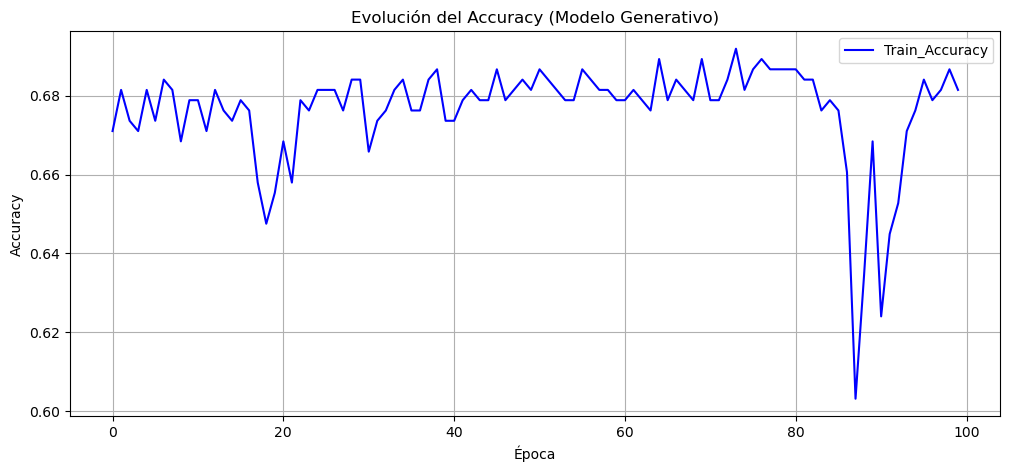

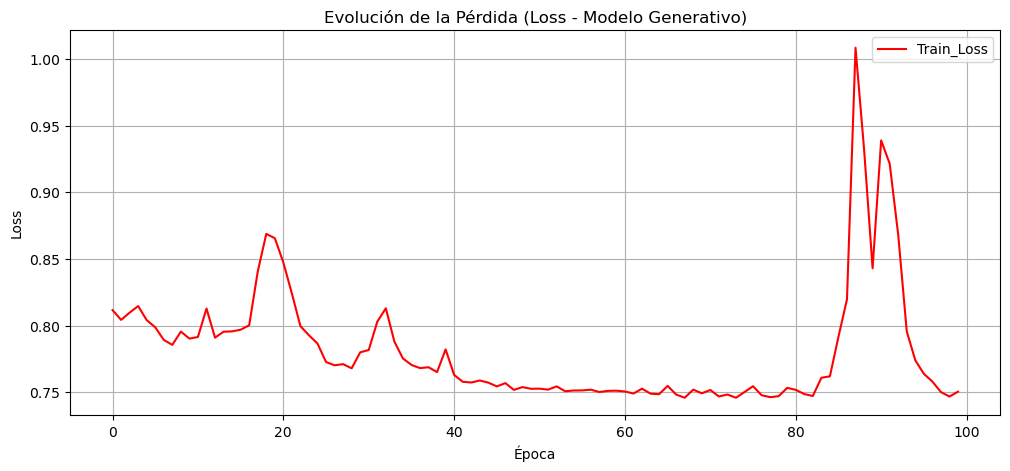

In [72]:
# --- Visualización del Aprendizaje del Modelo Generativo ---

# 1. Gráfica de Precisión (Accuracy)
# Queremos ver qué tan bien el modelo está "adivinando" la siguiente palabra del corpus.
plt.figure(figsize=(12,5)) # Definimos un lienzo ancho para observar bien la progresión
plt.plot(hist_gen.history["accuracy"], label="Train_Accuracy", color="blue")

# Configuración de etiquetas y estilo
plt.title("Evolución del Accuracy (Modelo Generativo)")
plt.xlabel("Época")        # Eje X: Las 100 iteraciones de entrenamiento
plt.ylabel("Accuracy")     # Eje Y: Porcentaje de acierto (0.0 a 1.0)
plt.legend()               # Muestra la leyenda de la línea azul
plt.grid(True)             # Facilita la lectura de los puntos de datos
plt.show()

# 2. Gráfica de Pérdida (Loss) de entrenamiento
# Esta gráfica es la más importante en generación: muestra cómo el modelo reduce su error.
plt.figure(figsize=(12,5))
plt.plot(hist_gen.history["loss"], label="Train_Loss", color="red")

# Configuración de etiquetas y estilo
plt.title("Evolución de la Pérdida (Loss - Modelo Generativo)")
plt.xlabel("Época")
plt.ylabel("Loss")         # Representa la entropía cruzada categórica
plt.legend()
plt.grid(True)
plt.show()

In [76]:
# --- Función de Muestreo Estocástico con Control de Temperatura ---

def sample_with_temperature(probabilidades, temperatura=1.0):
    """
    Modifica la distribución de probabilidad de la capa Softmax para 
    controlar la aleatoriedad de la predicción.
    """
    # 1. Convertimos a float64 para evitar errores de precisión decimal
    # (importante cuando manejamos números muy pequeños en probabilidad).
    probabilidades = np.asarray(probabilidades).astype("float64")

    # 2. Aplicamos la transformación de Temperatura:
    # Sumamos 1e-8 (un número minúsculo) para evitar errores matemáticos al calcular log(0).
    # La división por la temperatura altera la "confianza" del modelo:
    # - Si temp < 1: Las probabilidades altas suben y las bajas bajan (más conservador).
    # - Si temp > 1: Las probabilidades se igualan entre sí (más creativo/caótico).
    probabilidades = np.log(probabilidades + 1e-8) / temperatura

    # 3. Aplicamos la función exponencial para revertir el logaritmo
    exp_probabilidades = np.exp(probabilidades)

    # 4. Re-normalización (Aseguramos que la suma de todas las probabilidades sea exactamente 1)
    probabilidades = exp_probabilidades / np.sum(exp_probabilidades)

    # 5. Muestreo Multinomial:
    # En lugar de elegir siempre el índice con el valor más alto (Argmax),
    # elegimos un índice al azar respetando la nueva distribución de pesos.
    return np.random.choice(len(probabilidades), p=probabilidades)

In [78]:
# --- Implementación del Bucle de Generación Autoregresiva ---

def generar_texto(modelo, tokenizer, seed_text, max_sequence_len, 
                  n_palabras=6, temperatura=1.0):
    """
    Produce una secuencia de texto palabra por palabra, donde cada nueva palabra 
    depende de todo el contexto acumulado anteriormente.
    """
    
    # Iniciamos el proceso de expansión del texto original (seed_text)
    for _ in range(n_palabras):
        
        # 1. Transformación de Texto a Secuencia
        # Convertimos las palabras actuales en índices numéricos que la red entiende.
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        
        # 2. Normalización de Longitud (Padding)
        # Forzamos que la secuencia tenga el tamaño exacto de entrada (maxlen - 1).
        # El padding "pre" asegura que el modelo vea las palabras más recientes al final.
        token_list = pad_sequences([token_list], maxlen=max_sequence_len-1, padding="pre")
        
        # 3. Inferencia de Probabilidades
        # El modelo genera un vector (Softmax) con las probabilidades para cada palabra del vocabulario.
        # 'training=False' es importante para que capas como Dropout no afecten la predicción.
        predicted_probs = modelo(token_list, training=False).numpy()[0]
        
        # 4. Selección del Siguiente Token (Sampling)
        # Aplicamos la función de temperatura para decidir qué índice elegir entre las opciones.
        predicted_index = sample_with_temperature(predicted_probs, temperatura=temperatura)
        
        # 5. Decodificación de Índice a Palabra
        # Buscamos en el diccionario inverso del tokenizer para recuperar el texto.
        output_word = ""
        for palabra, indice in tokenizer.word_index.items():
            if indice == predicted_index:
                output_word = palabra
                break
        
        # 6. Verificación de Seguridad
        # Si por algún error el índice no mapea a una palabra, abortamos para evitar bucles infinitos.
        if output_word == "":
            break
        
        # 7. Actualización de la Semilla (Prompt)
        # La palabra generada se anexa al texto. En la siguiente iteración, 
        # esta palabra será parte del "pasado" que el modelo analizará.
        seed_text += " " + output_word
        
    return seed_text

In [80]:
# --- Fase de Inferencia: Generación de Texto con Prompts ---

# 1. Definimos una lista de "semillas" o frases iniciales (Prompts)
# El modelo intentará completar estas oraciones basándose en lo aprendido del corpus.
prompts = [
    "la inteligencia",
    "las lstm",
    "la salida",
    "el siguiente"
]

# 2. Iteramos sobre cada prompt para comparar resultados
for prompt in prompts:
    print(f"🚀 Prompt inicial: '{prompt}'")

    # Generación Conservadora (Temperatura 0.7):
    # El modelo tiende a elegir palabras más probables y seguras. 
    # Suele ser más coherente pero menos sorprendente.
    print(f" 🔹 Temperatura 0.7: {generar_texto(
        modelo_gen, 
        tokenizer_gen, 
        prompt, 
        max_sequence_len, 
        n_palabras=6, 
        temperatura=0.7
    )}")

    # Generación Creativa (Temperatura 1.0):
    # El modelo respeta la distribución original de probabilidades.
    # Introduce mayor variedad y puede construir frases menos predecibles.
    print(f" 🔸 Temperatura 1.0: {generar_texto(
        modelo_gen, 
        tokenizer_gen, 
        prompt, 
        max_sequence_len, 
        n_palabras=6, 
        temperatura=1.0
    )}")

    # Separador visual para diferenciar cada experimento
    print("-" * 90)

🚀 Prompt inicial: 'la inteligencia'
 🔹 Temperatura 0.7: la inteligencia artificial mejora procesos texto eficiencia plazo
 🔸 Temperatura 1.0: la inteligencia artificial necesita datos industrias eficiencia eficiencia
------------------------------------------------------------------------------------------
🚀 Prompt inicial: 'las lstm'
 🔹 Temperatura 0.7: las lstm reducen el gradiente desvaneciente mascara mascara
 🔸 Temperatura 1.0: las lstm usan compuertas para controlar memoria mascara
------------------------------------------------------------------------------------------
🚀 Prompt inicial: 'la salida'
 🔹 Temperatura 0.7: la salida softmax distribuye masa entre tokens tokens
 🔸 Temperatura 1.0: la salida softmax produce probabilidades probabilidades probable probable
------------------------------------------------------------------------------------------
🚀 Prompt inicial: 'el siguiente'
 🔹 Temperatura 0.7: el siguiente token depende de la historia longitud
 🔸 Temperatura 1.0: el 